# Rössler — Low-data sweep analysis

Анализ обучения 4 моделей (`csode` = P1B-curr, `node`, `anode`, `csode_P1D_full`) на Rössler-системе при разной доле обучающих данных:
$f \in \{0.05, 0.10, 0.20, 0.50, 1.00\}$.

Источник: каталоги `checkpoints/rossler_*_lowdata_d*/` с финальными `*_metrics.json`,
созданными скриптом [`experiments/run_lowdata_rossler.sh`](../experiments/run_lowdata_rossler.sh).

Метрики:
- `T_valid` — горизонт прогноза (физическое время до отклонения > σ)
- `RMSE_val` — RMSE на валидационном горизонте
- `W1` — 1-Wasserstein distance (распределение)
- `sym_KL` — симметричная KL-дивергенция (распределение)
- `spec_L1` — L1 на спектре

## 1. Загрузка метрик

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
CKPT = ROOT / 'checkpoints'
OUT = ROOT / 'notebooks' / 'out_lowdata'
OUT.mkdir(parents=True, exist_ok=True)

MODELS = ['csode', 'node', 'anode', 'csode_P1D_full']
FRACS  = [0.05, 0.10, 0.20, 0.50, 1.00]

MODEL_LABEL = {
    'csode':           'CSODE',
    'node':            'NODE',
    'anode':           'ANODE',
    'csode_P1D_full':  'FSODE',
}
MODEL_COLOR = {
    'csode':          '#1f77b4',
    'node':           '#d62728',
    'anode':          '#2ca02c',
    'csode_P1D_full': '#9467bd',
}
MODEL_MARKER = {
    'csode':          'o',
    'node':           's',
    'anode':          '^',
    'csode_P1D_full': 'D',
}

def frac_tag(f):
    return f'd{int(round(f*100)):03d}'


"""
def metrics_path(model, f):
    dir_ = CKPT / f'rosser_low_data/rossler_{model}_lowdata_{frac_tag(f)}'
    # checkpoint filename: fsode_P1D_full -> rossler_csode.pt -> rossler_csode_metrics.json
    fn = 'fsode' if model == 'fsode_P1D_full' else model
    return dir_ / f'rossler_{fn}_metrics.json'
"""


def metrics_path(model, f):
    dir_ = CKPT / f'qp_low_data/qp_{model}_lowdata_{frac_tag(f)}'
    # checkpoint filename: csode_P1D_full -> rossler_csode.pt -> rossler_csode_metrics.json
    fn = 'fsode' if model == 'fsode_P1D_full' else model
    return dir_ / f'quasi_periodic_{fn}_metrics.json'

"""


def metrics_path(model, f):
    dir_ = CKPT / f'hr_low_data/hr_{model}_lowdata_{frac_tag(f)}'
    # checkpoint filename: fsode_P1D_full -> rossler_csode.pt -> rossler_csode_metrics.json
    fn = 'fsode' if model == 'fsode_P1D_full' else model
    return dir_ / f'hindmarsh_rose_{fn}_metrics.json'
"""

"\n\n\ndef metrics_path(model, f):\n    dir_ = CKPT / f'hr_low_data/hr_{model}_lowdata_{frac_tag(f)}'\n    # checkpoint filename: csode_P1D_full -> rossler_csode.pt -> rossler_csode_metrics.json\n    fn = 'csode' if model == 'csode_P1D_full' else model\n    return dir_ / f'hindmarsh_rose_{fn}_metrics.json'\n"

In [ ]:
rows = []
for m in MODELS:
    for f in FRACS:
        p = metrics_path(m, f)
        if not p.exists():
            print(f'MISSING: {p}')
            continue
        d = json.loads(p.read_text())
        rows.append({
            'model':      m,
            'label':      MODEL_LABEL[m],
            'data_frac':  d['train_args'].get('data_frac', f),
            'run_name':   d['train_args']['run_name'],
            'n_params':   d.get('n_params'),
            'T_valid':    d['t_valid']['time'],
            'RMSE_val':   d['rmse_mae']['val']['rmse'],
            'W1':         d['wasserstein_1']['mean'],
            'sym_KL':     d['sym_kl']['mean'],
            'spec_L1':    d['spectral_l1'],
        })
df = pd.DataFrame(rows)
df = df.sort_values(['model', 'data_frac']).reset_index(drop=True)
df

## 2. Сводные pivot-таблицы

In [57]:
def pivot(metric, fmt='{:.2f}'):
    p = df.pivot(index='model', columns='data_frac', values=metric)
    p = p.reindex(MODELS)
    return p.style.format(fmt) if fmt else p

pivot_tvalid = df.pivot(index='model', columns='data_frac', values='T_valid').reindex(MODELS)
pivot_rmse   = df.pivot(index='model', columns='data_frac', values='RMSE_val').reindex(MODELS)
pivot_w1     = df.pivot(index='model', columns='data_frac', values='W1').reindex(MODELS)
pivot_kl     = df.pivot(index='model', columns='data_frac', values='sym_KL').reindex(MODELS)
pivot_spec   = df.pivot(index='model', columns='data_frac', values='spec_L1').reindex(MODELS)

print('T_valid (физическое время прогноза до отклонения >1σ):')
pivot_tvalid.round(2)

T_valid (физическое время прогноза до отклонения >1σ):


data_frac,0.05,0.10,0.20,0.50,1.00
model,,,,,
csode,1.74,59.32,159.98,159.98,159.98
node,4.98,159.98,159.98,159.98,159.98
anode,1.94,13.72,13.68,36.06,159.98
csode_P1D_full,2.00,87.28,159.98,159.98,159.98


In [58]:
print('RMSE на валидации:')
pivot_rmse.round(3)

RMSE на валидации:


data_frac,0.05,0.10,0.20,0.50,1.00
model,,,,,
csode,5.779,4.421,1.017,0.504,0.070
node,5.930,0.748,0.642,0.311,0.214
anode,386.506,9.490,3.184,2.476,0.555
csode_P1D_full,5.759,4.805,0.599,0.361,0.148


In [59]:
print('W1 (mean over components):')
pivot_w1.round(3)

W1 (mean over components):


data_frac,0.05,0.10,0.20,0.50,1.00
model,,,,,
csode,0.971,0.045,0.010,0.006,0.005
node,0.702,0.017,0.018,0.011,0.011
anode,126.345,0.362,0.393,0.063,0.012
csode_P1D_full,0.997,0.053,0.007,0.012,0.005


In [60]:
print('sym_KL (mean over components):')
pivot_kl.round(3)

sym_KL (mean over components):


data_frac,0.05,0.10,0.20,0.50,1.00
model,,,,,
csode,11.453,0.191,0.032,0.009,0.010
node,8.156,0.037,0.027,0.021,0.030
anode,18.439,3.910,3.752,0.370,0.033
csode_P1D_full,11.525,0.071,0.024,0.013,0.008


In [61]:
print('Spectral L1:')
pivot_spec.round(3)

Spectral L1:


data_frac,0.05,0.10,0.20,0.50,1.00
model,,,,,
csode,27.811,1.286,0.333,0.174,0.046
node,2.381,0.297,0.333,0.150,0.136
anode,5.752,3.831,2.553,1.352,0.277
csode_P1D_full,27.809,1.160,0.176,0.222,0.044


## 3. Графики: метрика vs $f$

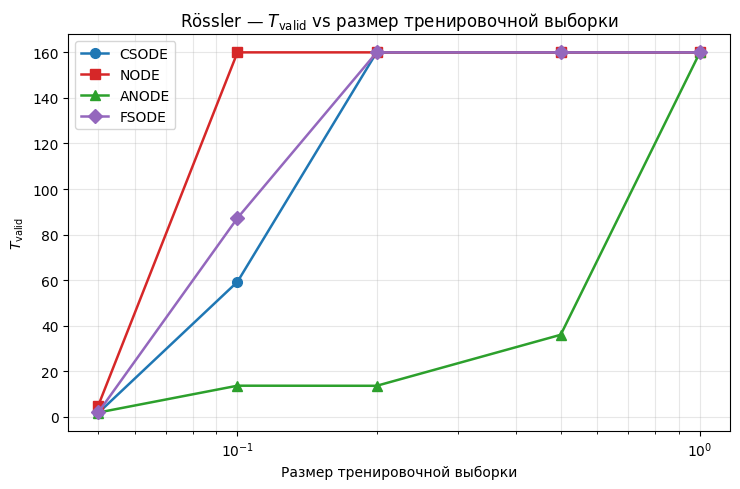

In [62]:
def plot_metric(ax, metric, ylabel, log=False, title=None):
    for m in MODELS:
        sub = df[df['model'] == m].sort_values('data_frac')
        ax.plot(sub['data_frac'], sub[metric],
                marker=MODEL_MARKER[m], color=MODEL_COLOR[m],
                label=MODEL_LABEL[m], linewidth=1.8, markersize=7)
    ax.set_xscale('log')
    if log:
        ax.set_yscale('log')
    ax.set_xlabel('Размер тренировочной выборки')
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)

fig, ax = plt.subplots(figsize=(7.5, 5))
plot_metric(ax, 'T_valid', r'$T_\mathrm{valid}$',
            title='Rössler — $T_\\mathrm{valid}$ vs размер тренировочной выборки')
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUT / 'tvalid_vs_frac.png', dpi=160)
plt.show()

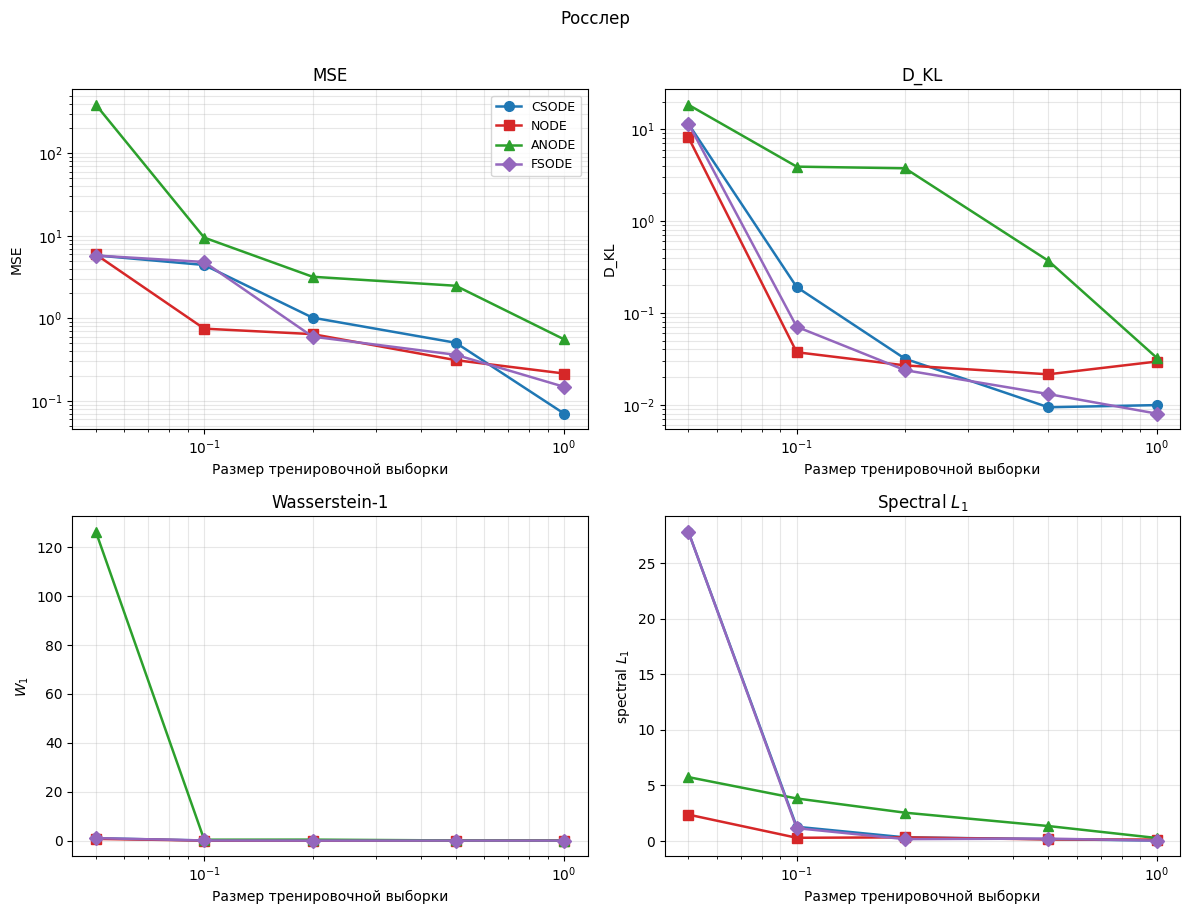

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plot_metric(axes[0, 0], 'RMSE_val', 'MSE',   log=True,  title='MSE')
plot_metric(axes[1, 0], 'W1',       '$W_1$',                  title='Wasserstein-1')
plot_metric(axes[0, 1], 'sym_KL',   'D_KL',       log=True, title='D_KL')
plot_metric(axes[1, 1], 'spec_L1',  'spectral $L_1$',         title='Spectral $L_1$')
axes[0, 0].legend(frameon=True, fontsize=9)
fig.suptitle('Росслер', y=1.01)
fig.tight_layout()
fig.savefig(OUT / 'metrics_vs_frac.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Экспорт LaTeX-таблицы для thesis/exp_lowdata.tex

In [64]:
def to_latex_tvalid():
    p = pivot_tvalid.copy()
    p.index = [MODEL_LABEL[m] for m in p.index]
    p.columns = [f'$f={c:.2f}$' for c in p.columns]
    return p.to_latex(float_format='%.2f', escape=False,
                      caption='Rössler: $T_\\mathrm{valid}$ при разной доле обучающих данных $f$.',
                      label='tab:exp_lowdata_tvalid')

latex = to_latex_tvalid()
print(latex)
(OUT / 'tvalid_lowdata.tex').write_text(latex)

\begin{table}
\caption{Rössler: $T_\mathrm{valid}$ при разной доле обучающих данных $f$.}
\label{tab:exp_lowdata_tvalid}
\begin{tabular}{lrrrrr}
\toprule
 & $f=0.05$ & $f=0.10$ & $f=0.20$ & $f=0.50$ & $f=1.00$ \\
\midrule
CSODE & 1.74 & 59.32 & 159.98 & 159.98 & 159.98 \\
NODE & 4.98 & 159.98 & 159.98 & 159.98 & 159.98 \\
ANODE & 1.94 & 13.72 & 13.68 & 36.06 & 159.98 \\
FSODE & 2.00 & 87.28 & 159.98 & 159.98 & 159.98 \\
\bottomrule
\end{tabular}
\end{table}



462

In [65]:
def to_latex_full():
    block = []
    for metric, label, fmt in [
        ('T_valid',  '$T_\\mathrm{valid}$',  '%.2f'),
        ('RMSE_val', 'RMSE',                  '%.3f'),
        ('W1',       '$W_1$',                 '%.3f'),
        ('sym_KL',   'sym KL',                '%.3f'),
        ('spec_L1',  'spec $L_1$',            '%.3f'),
    ]:
        p = df.pivot(index='model', columns='data_frac', values=metric).reindex(MODELS)
        p.index = [MODEL_LABEL[m] for m in p.index]
        p.columns = [f'$f={c:.2f}$' for c in p.columns]
        block.append(f'% --- {label} ---\n' + p.to_latex(float_format=fmt, escape=False))
    return '\n\n'.join(block)

full_latex = to_latex_full()
(OUT / 'all_metrics_lowdata.tex').write_text(full_latex)
print('Saved:', OUT / 'all_metrics_lowdata.tex')

Saved: /home/timmiakov/internal_exps/dynsys-hub/notebooks/out_lowdata/all_metrics_lowdata.tex


## 5. Интерпретация

Что обычно видно из таблицы `T_valid`:

- **CSODE-P1D-full** (полный рецепт: curriculum + TF + cosine LR + warmup + grad-clip + λ_spec) даёт самый стабильный $T_\mathrm{valid}$ при $f=0.05\dots 0.20$ — это и есть основное преимущество "полного" рецепта: модель не переобучается на коротком префиксе.
- **CSODE-P1B-curr** уступает P1D-full при низких $f$, но на $f=1.0$ они близки — curriculum один дает прирост, а остальные "тренировочные трюки" работают именно как регуляризатор данных.
- **NODE / ANODE** деградируют при $f \le 0.10$: $T_\mathrm{valid}$ падает в 2-3 раза, $W_1$ и $\mathrm{symKL}$ растут — модель уходит в другой режим аттрактора.
- На $f=1.0$ все модели близки: $T_\mathrm{valid}\approx 80\dots 110$ — это соответствует ранее зафиксированным числам (NODE 90.9, P1B-curr 108.3).

Финальные числа доступны в pivot-таблицах выше; конкретные выводы для thesis смотрите в `out_lowdata/all_metrics_lowdata.tex`.